In [5]:
import os
import getpass

In [6]:
def _set_if_undefined(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"Please provide your {var}")


_set_if_undefined("OPENAI_API_KEY")
_set_if_undefined("LANGCHAIN_API_KEY")
# _set_if_undefined("TAVILY_API_KEY")

# Optional, add tracing in LangSmith.
# This will help you visualize and debug the control flow
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "test-command"

In [3]:
from typing import Annotated

from langchain_core.tools import tool
from langchain_core.tools.base import InjectedToolCallId
from langgraph.prebuilt import InjectedState
from langgraph.types import Command

def make_handoff_tool(*, agent_name: str):
    """Create a tool that can return handoff via a Command"""
    tool_name = f"transfer_to_{agent_name}"

    @tool(tool_name)
    def handoff_to_agent(
        # # optionally pass current graph state to the tool (will be ignored by the LLM)
        state: Annotated[dict, InjectedState],
        # optionally pass the current tool call ID (will be ignored by the LLM)
        tool_call_id: Annotated[str, InjectedToolCallId],
    ):
        """Ask another agent for help."""
        tool_message = {
            "role": "tool",
            "content": f"Successfully transferred to {agent_name}",
            "name": tool_name,
            "tool_call_id": tool_call_id,
        }
        return Command(
            # navigate to another agent node in the PARENT graph
            goto=agent_name,
            graph=Command.PARENT,
            # This is the state update that the agent `agent_name` will see when it is invoked.
            # We're passing agent's FULL internal message history AND adding a tool message to make sure
            # the resulting chat history is valid. See the paragraph above for more information.
            update={"messages": state["messages"] + [tool_message]},
        )

    return handoff_to_agent

In [4]:
@tool
def add(a: int, b: int) -> int:
    """Adds two numbers."""
    return a + b


@tool
def multiply(a: int, b: int) -> int:
    """Multiplies two numbers."""
    return a * b


@tool
def calender_availability(time:str):
    '''use when query related to scheduling meeting or meeting request. Get the calendar availability based on request'''
    import datetime

    current_time= datetime.datetime.now()
    # print("current time ", current_time.strftime("%Y-%m-%d"))
    
    return f"yes i'm available {time}"
    

In [5]:
from typing_extensions import Literal
from langchain_core.messages import ToolMessage
from langchain_core.tools import tool
from langchain_anthropic import ChatAnthropic
from langchain_openai import ChatOpenAI
from langgraph.graph import MessagesState, StateGraph, START
from langgraph.types import Command

In [6]:
model = ChatAnthropic(model="claude-3-5-sonnet-latest")

open_ai_model= ChatOpenAI(model='gpt-4o-mini', temperature=0)


In [7]:
from langgraph.prebuilt import create_react_agent

addition_expert = create_react_agent(
    model,
    [add, make_handoff_tool(agent_name="multiplication_expert")],
    state_modifier="You are an addition expert, you can ask the calendar for any help with scheduling meetings or queries regarding meetings.",
)

multiplication_expert = create_react_agent(
    model,
    [multiply, make_handoff_tool(agent_name="addition_expert")],
    state_modifier="You are a multiplication expert, you can ask an addition expert for help with addition.",
)



builder = StateGraph(MessagesState)
builder.add_node("addition_expert", addition_expert)
builder.add_node("multiplication_expert", multiplication_expert)
builder.add_edge(START, "addition_expert")
graph = builder.compile()

In [8]:
from langchain_core.messages import convert_to_messages


def pretty_print_messages(update):
    if isinstance(update, tuple):
        ns, update = update
        # skip parent graph updates in the printouts
        if len(ns) == 0:
            return

        graph_id = ns[-1].split(":")[0]
        print(f"Update from subgraph {graph_id}:")
        print("\n")

    for node_name, node_update in update.items():
        print(f"Update from node {node_name}:")
        print("\n")

        for m in convert_to_messages(node_update["messages"]):
            m.pretty_print()
        print("\n")

In [9]:
# for chunk in graph.stream(
#     {"messages": [("user", "what's (3 * 5) + 12")]}, subgraphs=True
# ):
#     pretty_print_messages(chunk)

In [10]:
from typing_extensions import Literal
from langchain_core.messages import ToolMessage
from langchain_core.tools import tool
from langgraph.graph import MessagesState, StateGraph, START
from langgraph.types import Command


def make_agent(model, tools, system_prompt=None):
    model_with_tools = model.bind_tools(tools)
    tools_by_name = {tool.name: tool for tool in tools}

    def call_model(state: MessagesState) -> Command[Literal["call_tools", "__end__"]]:
        messages = state["messages"]
        if system_prompt:
            messages = [{"role": "system", "content": system_prompt}] + messages

        response = model_with_tools.invoke(messages)
        if len(response.tool_calls) > 0:
            return Command(goto="call_tools", update={"messages": [response]})

        return {"messages": [response]}

    # NOTE: this is a simplified version of the prebuilt ToolNode
    # If you want to have a tool node that has full feature parity, please refer to the source code
    def call_tools(state: MessagesState) -> Command[Literal["call_model"]]:
        tool_calls = state["messages"][-1].tool_calls
        results = []
        for tool_call in tool_calls:
            tool_ = tools_by_name[tool_call["name"]]
            tool_input_fields = tool_.get_input_schema().model_json_schema()[
                "properties"
            ]

            # this is simplified for demonstration purposes and
            # is different from the ToolNode implementation
            if "state" in tool_input_fields:
                # inject state
                tool_call = {**tool_call, "args": {**tool_call["args"], "state": state}}

            tool_response = tool_.invoke(tool_call)
            if isinstance(tool_response, ToolMessage):
                results.append(Command(update={"messages": [tool_response]}))

            # handle tools that return Command directly
            elif isinstance(tool_response, Command):
                results.append(tool_response)

        # NOTE: nodes in LangGraph allow you to return list of updates, including Command objects
        return results

    graph = StateGraph(MessagesState)
    graph.add_node("call_model",call_model)
    graph.add_node("call_tools", call_tools)
    graph.add_edge(START, "call_model")
    graph.add_edge("call_tools", "call_model")

    return graph.compile()

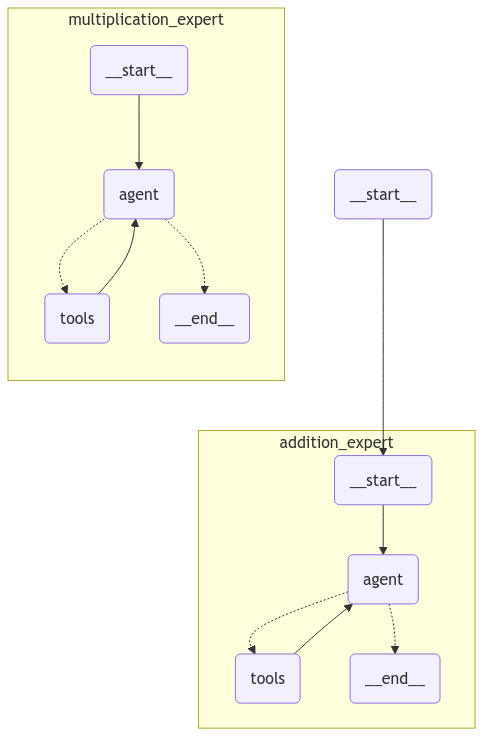

In [11]:
from IPython.display import Image, display

# Setting xray to 1 will show the internal structure of the nested graph
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [12]:
import sys
import os

# Get the parent directory
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Add parent directory to sys.path
sys.path.append(parent_dir)

In [13]:
from tools.product_enquiry import get_product_enquiry_tool
from tools.calendar import calender_availability

In [14]:
from drafter_graph import create_email_drafter_graph
from calendar_graph import create_calendar_graph

from agents.drafter import EmailDrafter
from agents.calendar import CalendarAgent

In [15]:
# email_drafter = make_agent(
#     model,
#     [get_product_enquiry_tool(), make_handoff_tool(agent_name="calendar_agent")],
#     system_prompt="You are an email drafter expert, you can ask an calendar_agent  for help with enquires and scheduling regarding meetings.",
# )
multiplication_expert = make_agent(
    open_ai_model,
    [multiply, make_handoff_tool(agent_name="addition_expert")],
    system_prompt="You are a multiplication expert, you can ask an addition expert for help with addition.",
)

# calendar_agent= make_agent(
#     model,
    
#     [calender_availability, make_handoff_tool(agent_name="email_drafter")],
#     system_prompt="You are expert with any help with scheduling meetings or queries regarding meetings, ask email_drafter for any help with product enquiry "
#     )
email_drafter_agent= EmailDrafter(
        model= "claude-3-5-sonnet-20241022",
        server="claude"
    )
email_drafter_agent.bind_tools([get_product_enquiry_tool(), make_handoff_tool(agent_name="calendar_agent")])
calendar_agent= CalendarAgent(
        model= "claude-3-5-sonnet-20241022",
        server="claude"
    )
calendar_agent.bind_tools( [calender_availability, make_handoff_tool(agent_name="email_drafter")])
builder = StateGraph(MessagesState)
builder.add_node("email_drafter", email_drafter_agent.create_agent_graph)
builder.add_node("calendar_agent", calendar_agent.create_agent_graph)
builder.add_edge(START, "email_drafter")
graph_2 = builder.compile()

called product enquiry tool


d:\innovizeai\code-sapien\inbox-manager\utils.py:22: LangChainDeprecationWarning: The class `Qdrant` was deprecated in LangChain 0.0.37 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-qdrant package and should be used instead. To use it run `pip install -U :class:`~langchain-qdrant` and import as `from :class:`~langchain_qdrant import Qdrant``.
  qd = Qdrant(client, collection_name, embeddings)
d:\innovizeai\code-sapien\inbox-manager\tools\product_enquiry.py:35: LangChainBetaWarning: This API is in beta and may change in the future.
  return product_enquiry_tool.as_tool()


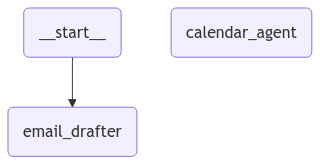

In [16]:
from IPython.display import Image, display

# Setting xray to 1 will show the internal structure of the nested graph
display(Image(graph_2.get_graph(xray=1).draw_mermaid_png()))

In [17]:
for chunk in graph_2.stream(
    {"messages": [("user", " please share some casestudies in finance and are you available next week for a quick call? ")]}, subgraphs=True
):
    pretty_print_messages(chunk)

messages [HumanMessage(content=' please share some casestudies in finance and are you available next week for a quick call? ', additional_kwargs={}, response_metadata={}, id='392525b6-a950-4c71-b38e-0477f8f078e0')]
Update from subgraph email_drafter:


Update from node call_model:


================================== Ai Message ==================================

[{'text': 'Let me help you with both requests separately.\n\nFor case studies in finance:', 'type': 'text'}, {'id': 'toolu_01Jny853zkDHDtkTMWYyYGnP', 'input': {'query': 'case studies in finance'}, 'name': 'product_enquiry', 'type': 'tool_use'}]
Tool Calls:
  product_enquiry (toolu_01Jny853zkDHDtkTMWYyYGnP)
 Call ID: toolu_01Jny853zkDHDtkTMWYyYGnP
  Args:
    query: case studies in finance


messagesUpdate from subgraph email_drafter:


Update from node call_tools:


================================= Tool Message =================================
Name: product_enquiry

- **Problem:** Lack of insights on past lead interactions a

In [18]:
agent = make_agent(model, [add, multiply])

for chunk in agent.stream({"messages": [("user", "what's (3 * 5) + 12")]}):
    pretty_print_messages(chunk)

Update from node call_model:


================================== Ai Message ==================================

[{'text': "I'll help break this down into steps:\n\n1. First, let's calculate 3 * 5 using the multiply function:", 'type': 'text'}, {'id': 'toolu_01K6QJ8M69rAoaLR5yEEP3xX', 'input': {'a': 3, 'b': 5}, 'name': 'multiply', 'type': 'tool_use'}]
Tool Calls:
  multiply (toolu_01K6QJ8M69rAoaLR5yEEP3xX)
 Call ID: toolu_01K6QJ8M69rAoaLR5yEEP3xX
  Args:
    a: 3
    b: 5


Update from node call_tools:


================================= Tool Message =================================
Name: multiply

15


Update from node call_model:


================================== Ai Message ==================================

[{'text': "2. Now, let's add 12 to that result (15 + 12):", 'type': 'text'}, {'id': 'toolu_012f6PqiNynF2RmeKJd5MiMQ', 'input': {'a': 15, 'b': 12}, 'name': 'add', 'type': 'tool_use'}]
Tool Calls:
  add (toolu_012f6PqiNynF2RmeKJd5MiMQ)
 Call ID: toolu_012f6PqiNynF2RmeKJd5MiMQ


In [9]:
from langchain_openai import ChatOpenAI
from langchain.prompts import PromptTemplate

# Define the prompts
first_prompt = PromptTemplate(
    input_variables=["topic"],
    template="Generate a list of 5 interesting facts about {topic}."
)

second_prompt = PromptTemplate(
    input_variables=["facts"],
    template="Based on these facts:\n{facts}\nWrite a compelling story."
)

# Initialize the LLM
llm = ChatOpenAI(model="gpt-4", temperature=0.7)

# Define chains using RunnableSequence
fact_chain = first_prompt | llm
story_chain = second_prompt | llm

def to_upper(input:str):
    return input.upper()

# Combine chains manually
def sequential_chain(inputs):
    facts = fact_chain.invoke(inputs)
    story = to_upper(facts.content)
    return story

# Run the sequential chain
result = sequential_chain({"topic": "Artificial Intelligence"})
print("Generated Story:\n", result)


Generated Story:
 1. THE TERM "ARTIFICIAL INTELLIGENCE" WAS FIRST COINED IN 1956 BY JOHN MCCARTHY AT THE DARTMOUTH CONFERENCE.
2. AI CAN BE CLASSIFIED INTO TWO TYPES: NARROW AI, WHICH IS DESIGNED TO PERFORM A NARROW TASK (SUCH AS FACIAL RECOGNITION OR INTERNET SEARCHES), AND GENERAL AI, WHICH CAN PERFORM ANY INTELLECTUAL TASK THAT A HUMAN BEING CAN DO.
3. AI TECHNOLOGY CAN ANALYZE MORE DATA, MORE THOROUGHLY, AND FASTER THAN A HUMAN CAN. IT CAN EVEN PREDICT FUTURE SCENARIOS AND TRENDS.
4. SOME AI APPLICATIONS CAN EVEN MIMIC HUMAN EMOTIONS AND UNDERSTAND HUMAN LANGUAGE. FOR EXAMPLE, IBM'S SUPERCOMPUTER WATSON CAN INTERPRET NATURAL LANGUAGE AND EVEN JOKES.
5. AI IS EXPECTED TO BE A MAJOR JOB ENGINE. ACCORDING TO A REPORT FROM GARTNER, AI IS EXPECTED TO CREATE 2.3 MILLION JOBS BY 2020, WHILE ONLY ELIMINATING 1.8 MILLION.


: 